# EDA: CESNET-TimeSeries24 数据探索性分析

**目的**：在建模之前充分理解数据特征，为后续预处理和模型选择提供依据。  
**对应论文**：数据集论文 "CESNET-TimeSeries24: Time Series Dataset..."  Section 4 (Technical Validation)  
**实验输出目录**：`experiments/01_eda/figures/`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['figure.figsize'] = (14, 5)
# 解决中文显示问题
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']
matplotlib.rcParams['axes.unicode_minus'] = False

from statsmodels.graphics.tsaplots import plot_acf
from pathlib import Path

DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../experiments/01_eda/figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'数据目录: {DATA_DIR.resolve()}')
print(f'输出目录: {OUTPUT_DIR.resolve()}')

数据目录: D:\WORKSPACE\systemandnetwork\final assigment\data
输出目录: D:\WORKSPACE\systemandnetwork\final assigment\experiments\01_eda\figures


---
## Step 1: 不同层级对比

**对应论文**：预测论文 Fig.2 — Example of different hierarchical levels  
**目的**：直观对比机构级、子网级、IP 地址级三条时间序列，验证论文"层级越高越稳定"的观察。

从三个层级各取 1 条序列，画 `n_bytes`（传输字节数）随时间的变化。

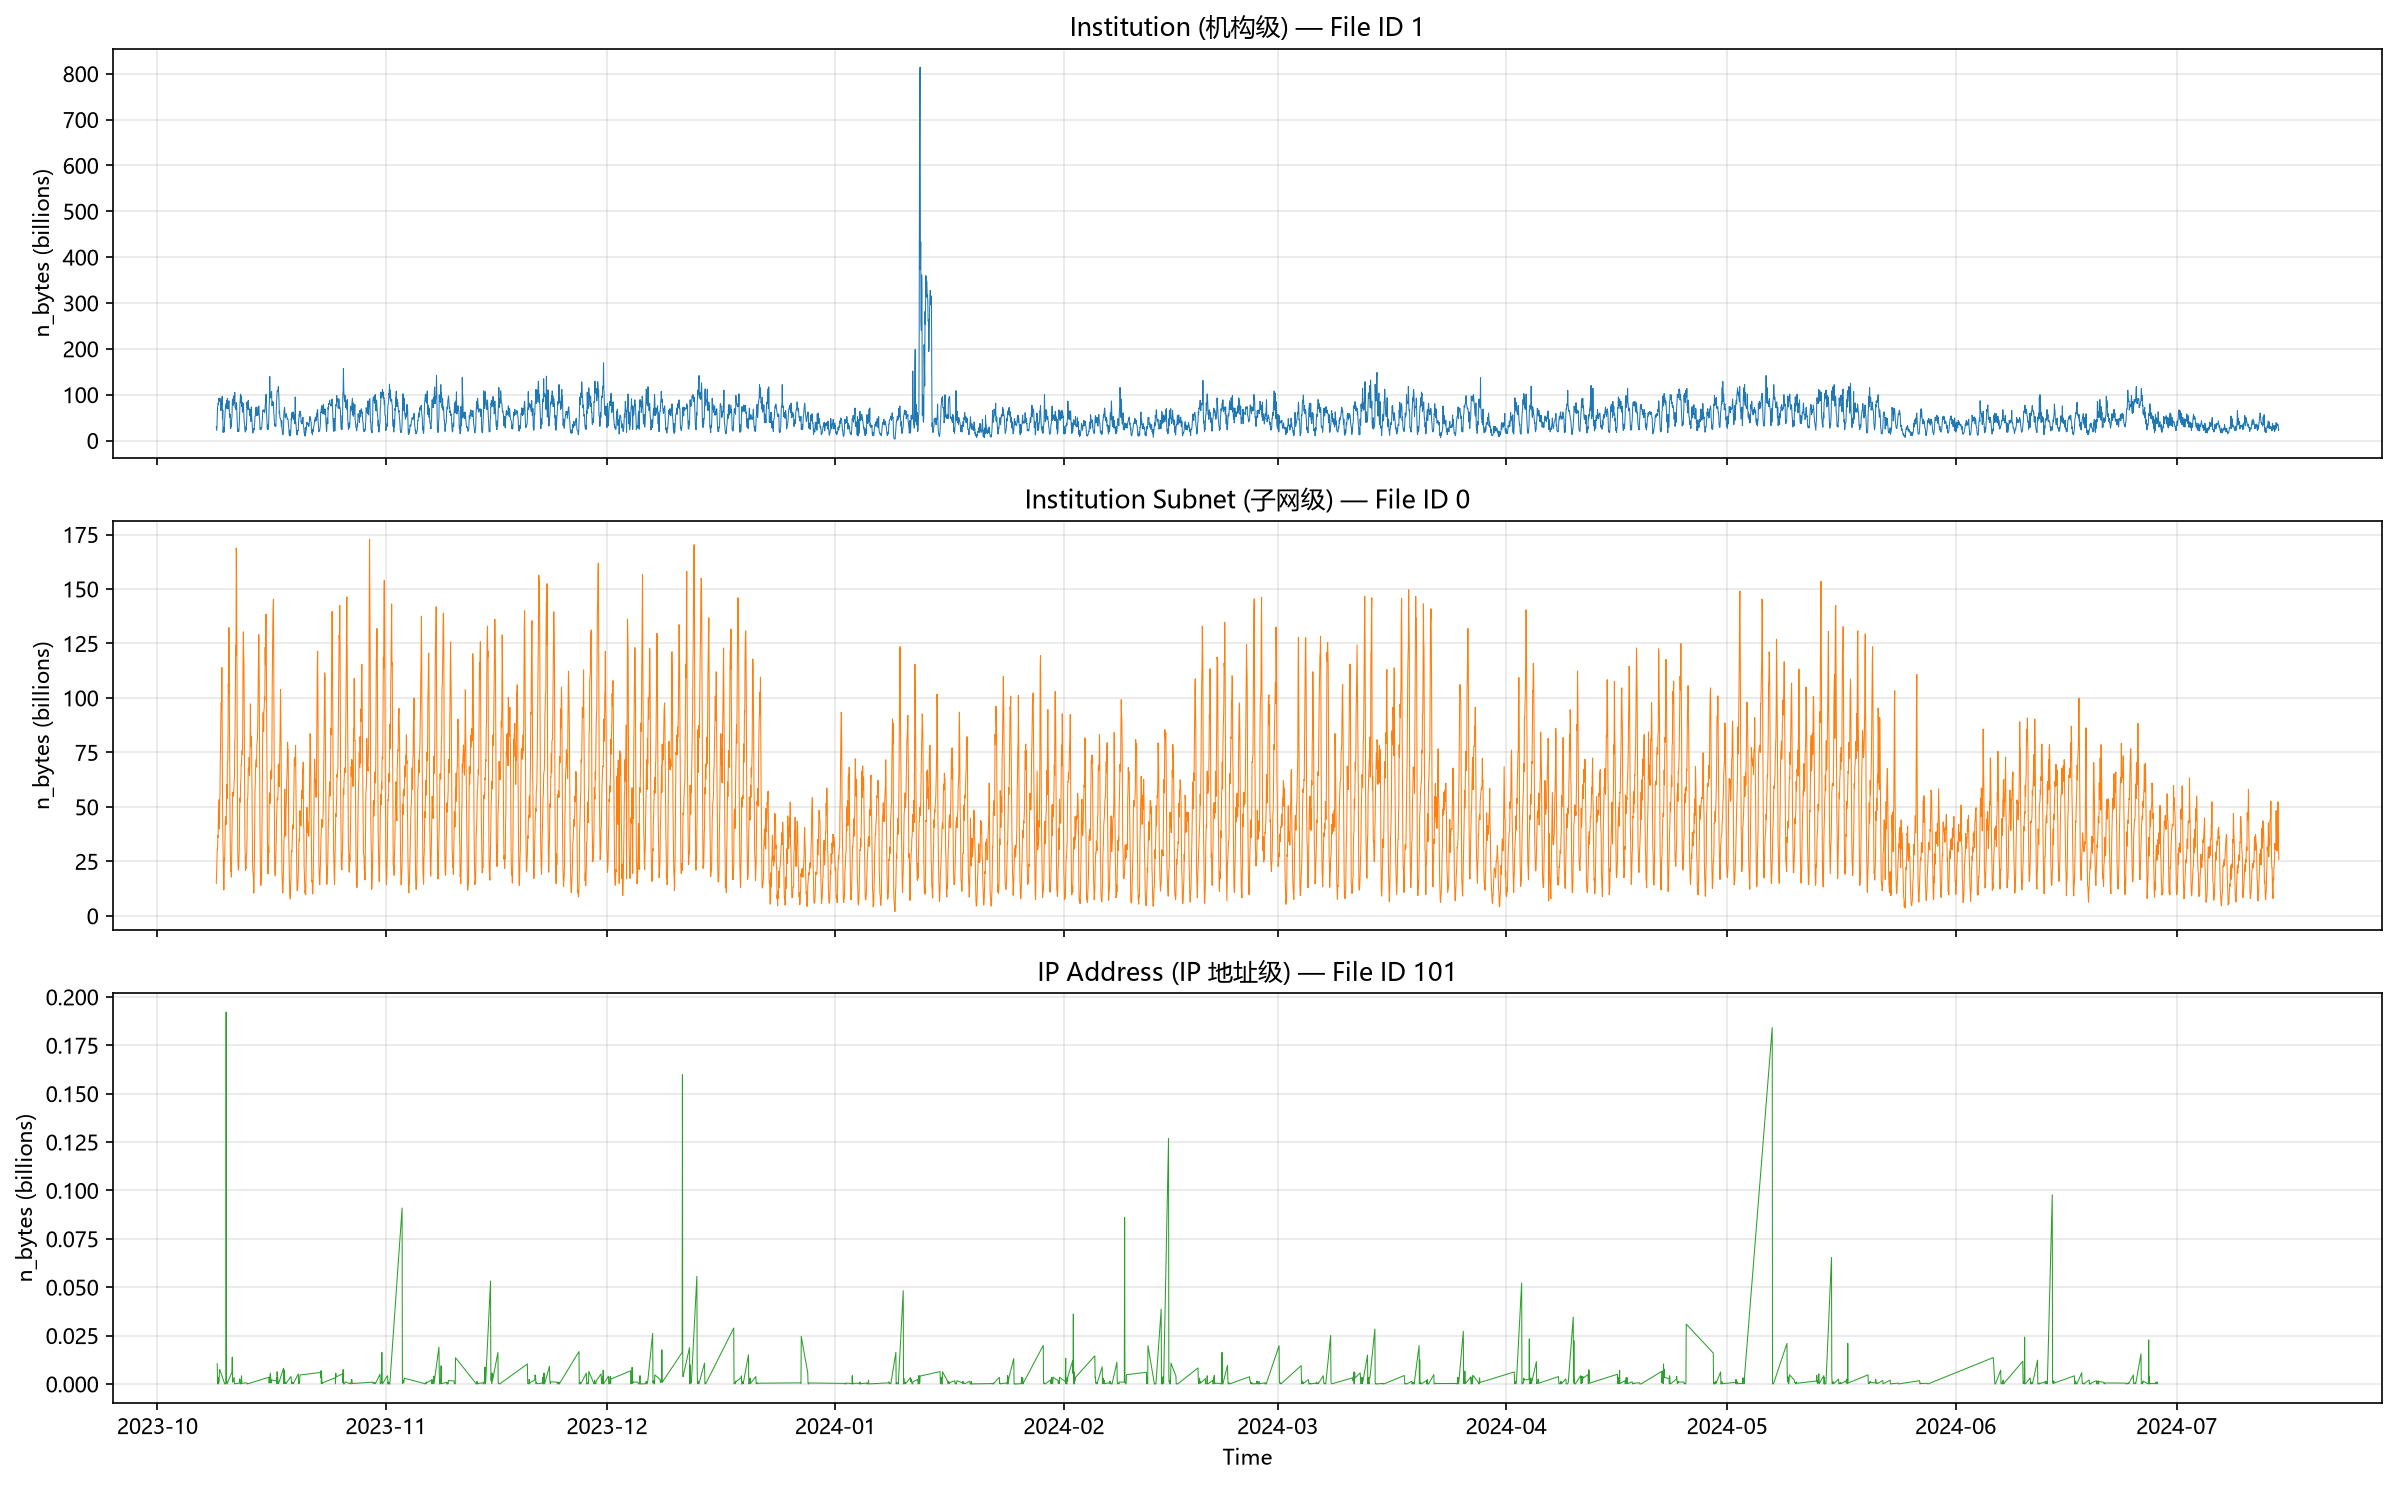

图片已保存: ..\experiments\01_eda\figures\01_hierarchical_comparison.png


In [2]:
def load_timeseries(group, agg='agg_1_hour', file_id=1):
    """加载某一条时间序列及其时间戳"""
    df = pd.read_csv(DATA_DIR / group / agg / f'{file_id}.csv')
    times = pd.read_csv(DATA_DIR / group / agg / 'times.csv')
    df = df.merge(times, on='id_time', how='left')
    df['time'] = pd.to_datetime(df['time'])
    return df.set_index('time')

inst = load_timeseries('institutions', file_id=1)
subnet = load_timeseries('institution_subnets', file_id=0)
ip = load_timeseries('ip_addresses_sample', file_id=101)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(inst.index, inst['n_bytes'] / 1e9, linewidth=0.5, color='#1f77b4')
axes[0].set_ylabel('n_bytes (billions)')
axes[0].set_title('Institution (机构级) — File ID 1')
axes[0].grid(True, alpha=0.3)

axes[1].plot(subnet.index, subnet['n_bytes'] / 1e9, linewidth=0.5, color='#ff7f0e')
axes[1].set_ylabel('n_bytes (billions)')
axes[1].set_title('Institution Subnet (子网级) — File ID 0')
axes[1].grid(True, alpha=0.3)

axes[2].plot(ip.index, ip['n_bytes'] / 1e9, linewidth=0.5, color='#2ca02c')
axes[2].set_ylabel('n_bytes (billions)')
axes[2].set_title('IP Address (IP 地址级) — File ID 101')
axes[2].grid(True, alpha=0.3)

plt.xlabel('Time')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_hierarchical_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'图片已保存: {OUTPUT_DIR / "01_hierarchical_comparison.png"}')

**观察要点：**
- 机构级：流量相对平滑、有明显的周期模式（工作日高、周末低）
- 子网级：与机构级形态接近，但噪声更大
- IP 级：非常稀疏，大量零值区间，规律性弱

这验证了论文的观察：**聚合级别越高，流量越稳定，预测越容易**。

---
## Step 2: 周期性分析

**对应论文依据**：预测论文 Table II 的窗口选择（24h/168h/720h）基于流量存在的周期性  
**目的**：确认数据中是否存在日周期（24h）和周周期（168h），为窗口选择提供依据。

先用原始数据画出局部放大图（直观感受周期），再画自相关图（ACF）定量确认。

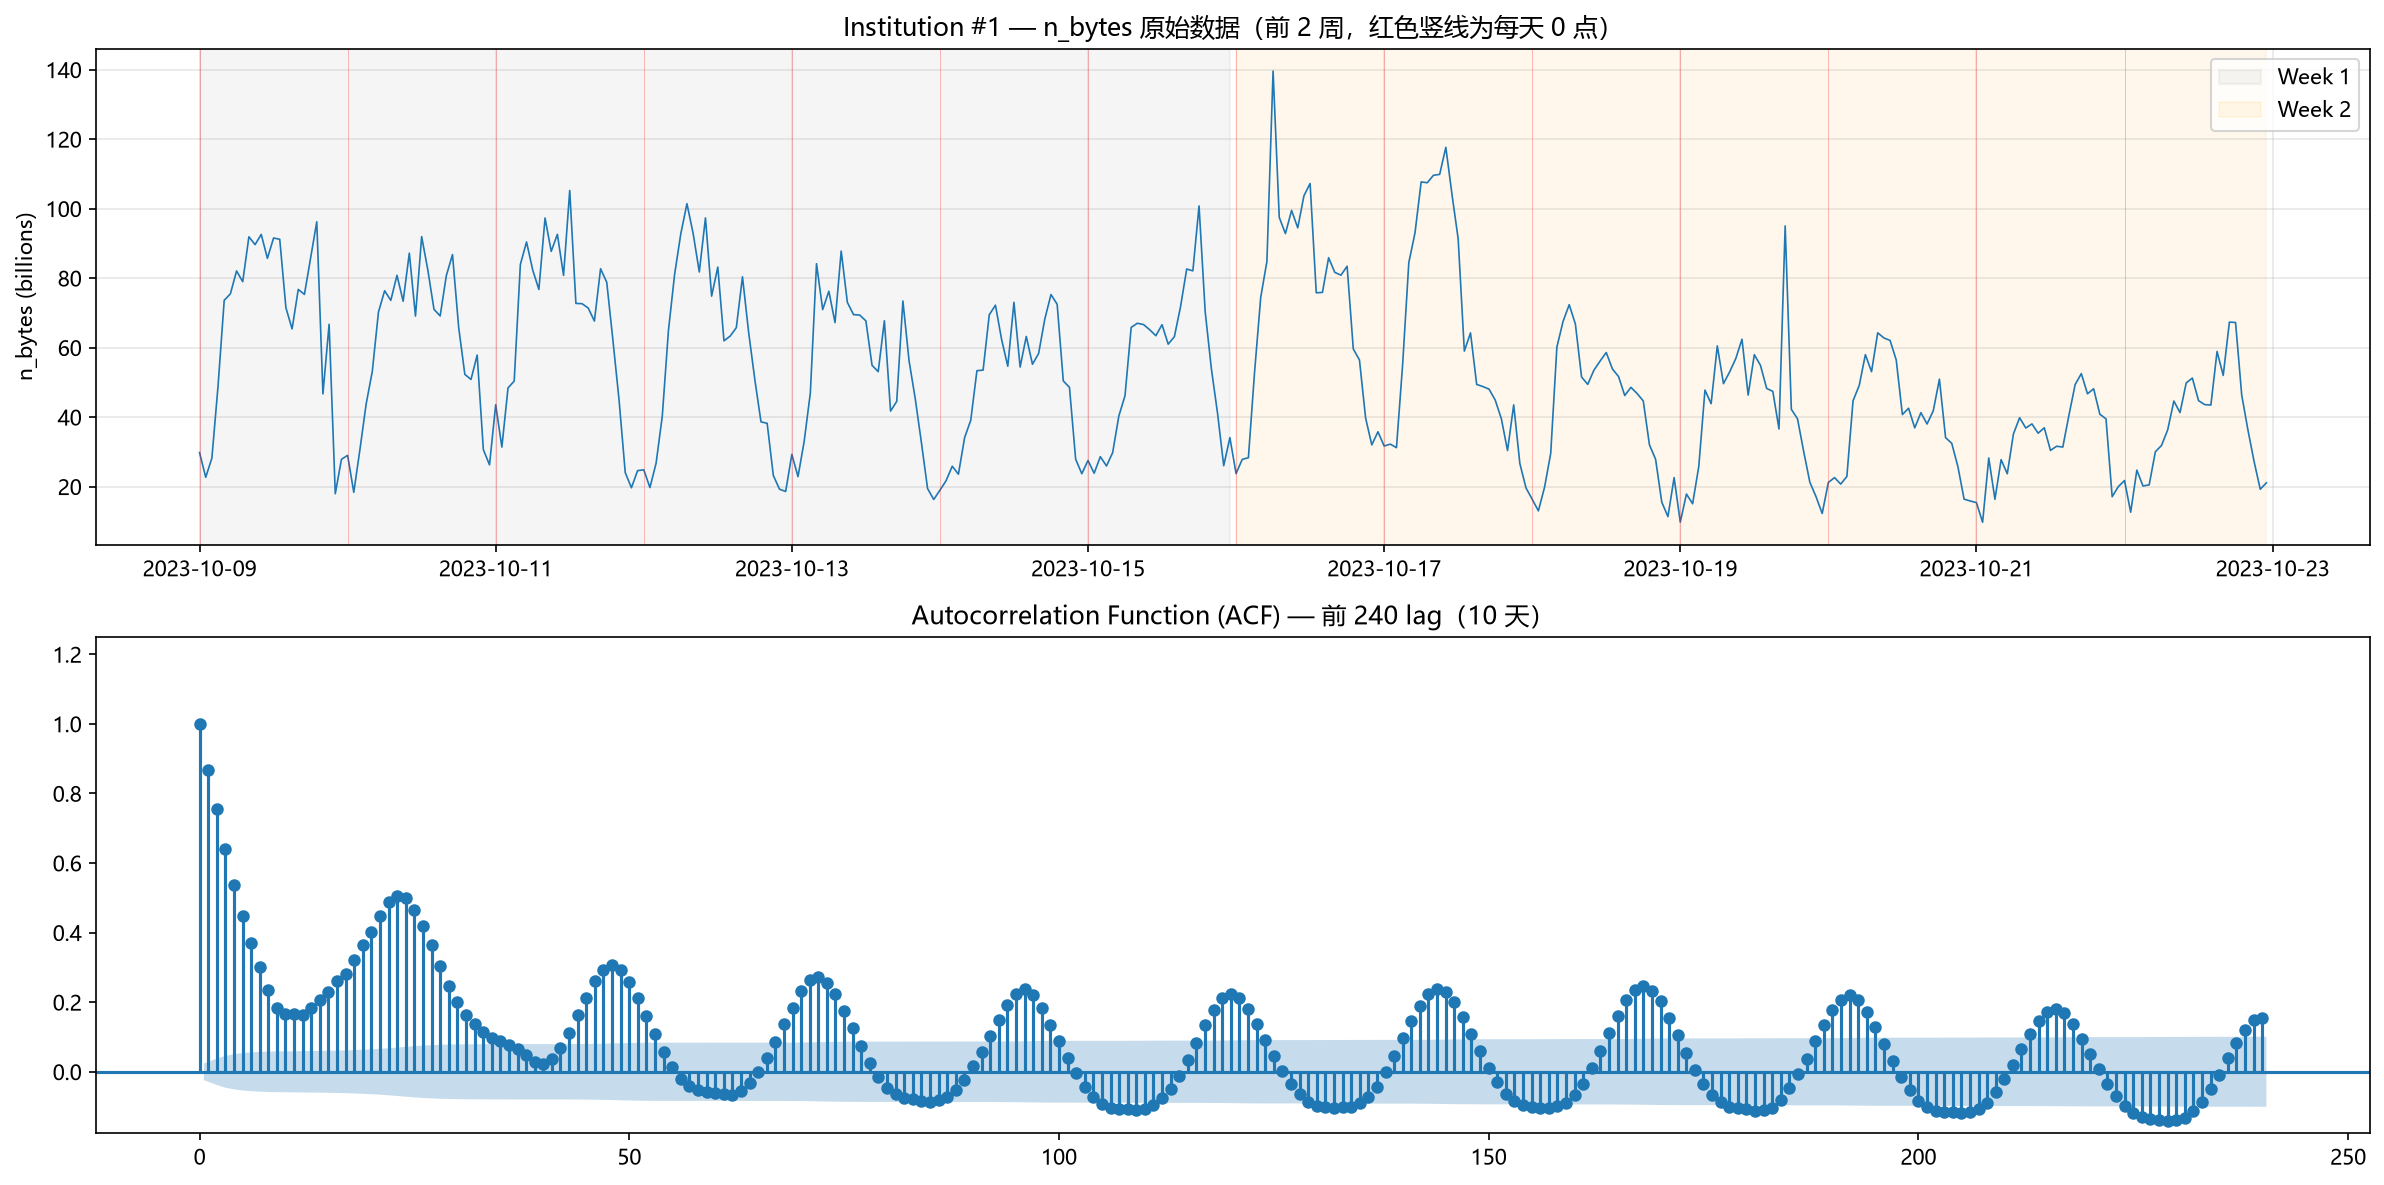

图片已保存: ..\experiments\01_eda\figures\02_periodicity_analysis.png


In [4]:
# 取机构级前 2 周数据画原始曲线
two_weeks = inst.iloc[:336]  # 336 hours = 14 days

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# 上半部分：原始数据
axes[0].plot(two_weeks.index, two_weeks['n_bytes'] / 1e9, linewidth=0.8, color='#1f77b4')
axes[0].axvspan(two_weeks.index[0], two_weeks.index[24*7 - 1], alpha=0.08, color='gray', label='Week 1')
axes[0].axvspan(two_weeks.index[24*7], two_weeks.index[-1], alpha=0.08, color='orange', label='Week 2')

# 标注每天的 0 点（帮助观察日周期）
for i in range(0, len(two_weeks), 24):
    axes[0].axvline(two_weeks.index[i], color='red', linewidth=0.3, alpha=0.4)

axes[0].set_ylabel('n_bytes (billions)')
axes[0].set_title('Institution #1 — n_bytes 原始数据（前 2 周，红色竖线为每天 0 点）')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 下半部分：自相关图
plot_acf(inst['n_bytes'].dropna(), lags=240, ax=axes[1], auto_ylims=True)
axes[1].set_title('Autocorrelation Function (ACF) — 前 240 lag（10 天）')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_periodicity_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'图片已保存: {OUTPUT_DIR / "02_periodicity_analysis.png"}')

**观察要点：**
- 原始曲线：每天有明显的波峰波谷（日周期），周中与周末模式不同（周周期）
- ACF 图：每隔 24h 出现一个峰值 → **日周期确认**，每隔 168h 出现更强峰值 → **周周期确认**

论文选择 24h（短期）、168h（7天）作为训练窗口是合理的。

---
## Step 3: 缺失值分析

**对应论文依据**：数据集论文 Section 4.1 "Gaps in time series" + Fig.8  
**目的**：统计缺失率分布，决定填充策略。论文指出 1h 聚合平均缺失率 ~60%，我需要验证自己的数据是否一致。

In [6]:
def compute_missing_rate(group, agg='agg_1_hour', max_files=None):
    """计算某个层级下所有序列的缺失率
    论文说的"缺失"不是 NaN，而是某些小时整行数据不存在（gap）。
    用 times.csv 里的预期时间点总数 vs 实际行数来计算。
    """
    data_dir = DATA_DIR / group / agg
    csv_files = sorted([f for f in data_dir.glob('*.csv') if f.name != 'times.csv' and f.name != 'identifiers.csv'])
    if max_files:
        csv_files = csv_files[:max_files]
    
    times = pd.read_csv(data_dir / 'times.csv')
    expected_count = len(times)
    
    rates = []
    for f in csv_files:
        df = pd.read_csv(f, usecols=['id_time'])
        actual_count = len(df)
        rate = (expected_count - actual_count) / expected_count * 100
        rates.append(rate)
    return np.array(rates)

print('基于时间间隙的缺失率计算...')
print('(注：论文说的"缺失"是指某些小时整行数据不存在，不是 NaN)')
print()
inst_missing = compute_missing_rate('institutions')
subnet_missing = compute_missing_rate('institution_subnets')
ip_missing = compute_missing_rate('ip_addresses_sample')

print(f'机构级:  平均 {inst_missing.mean():.1f}%, 中位数 {np.median(inst_missing):.1f}%')
print(f'子网级:  平均 {subnet_missing.mean():.1f}%, 中位数 {np.median(subnet_missing):.1f}%')
print(f'IP 级:   平均 {ip_missing.mean():.1f}%, 中位数 {np.median(ip_missing):.1f}%')

基于时间间隙的缺失率计算...
(注：论文说的"缺失"是指某些小时整行数据不存在，不是 NaN)

机构级:  平均 1.1%, 中位数 0.0%
子网级:  平均 3.8%, 中位数 0.0%
IP 级:   平均 79.0%, 中位数 92.6%


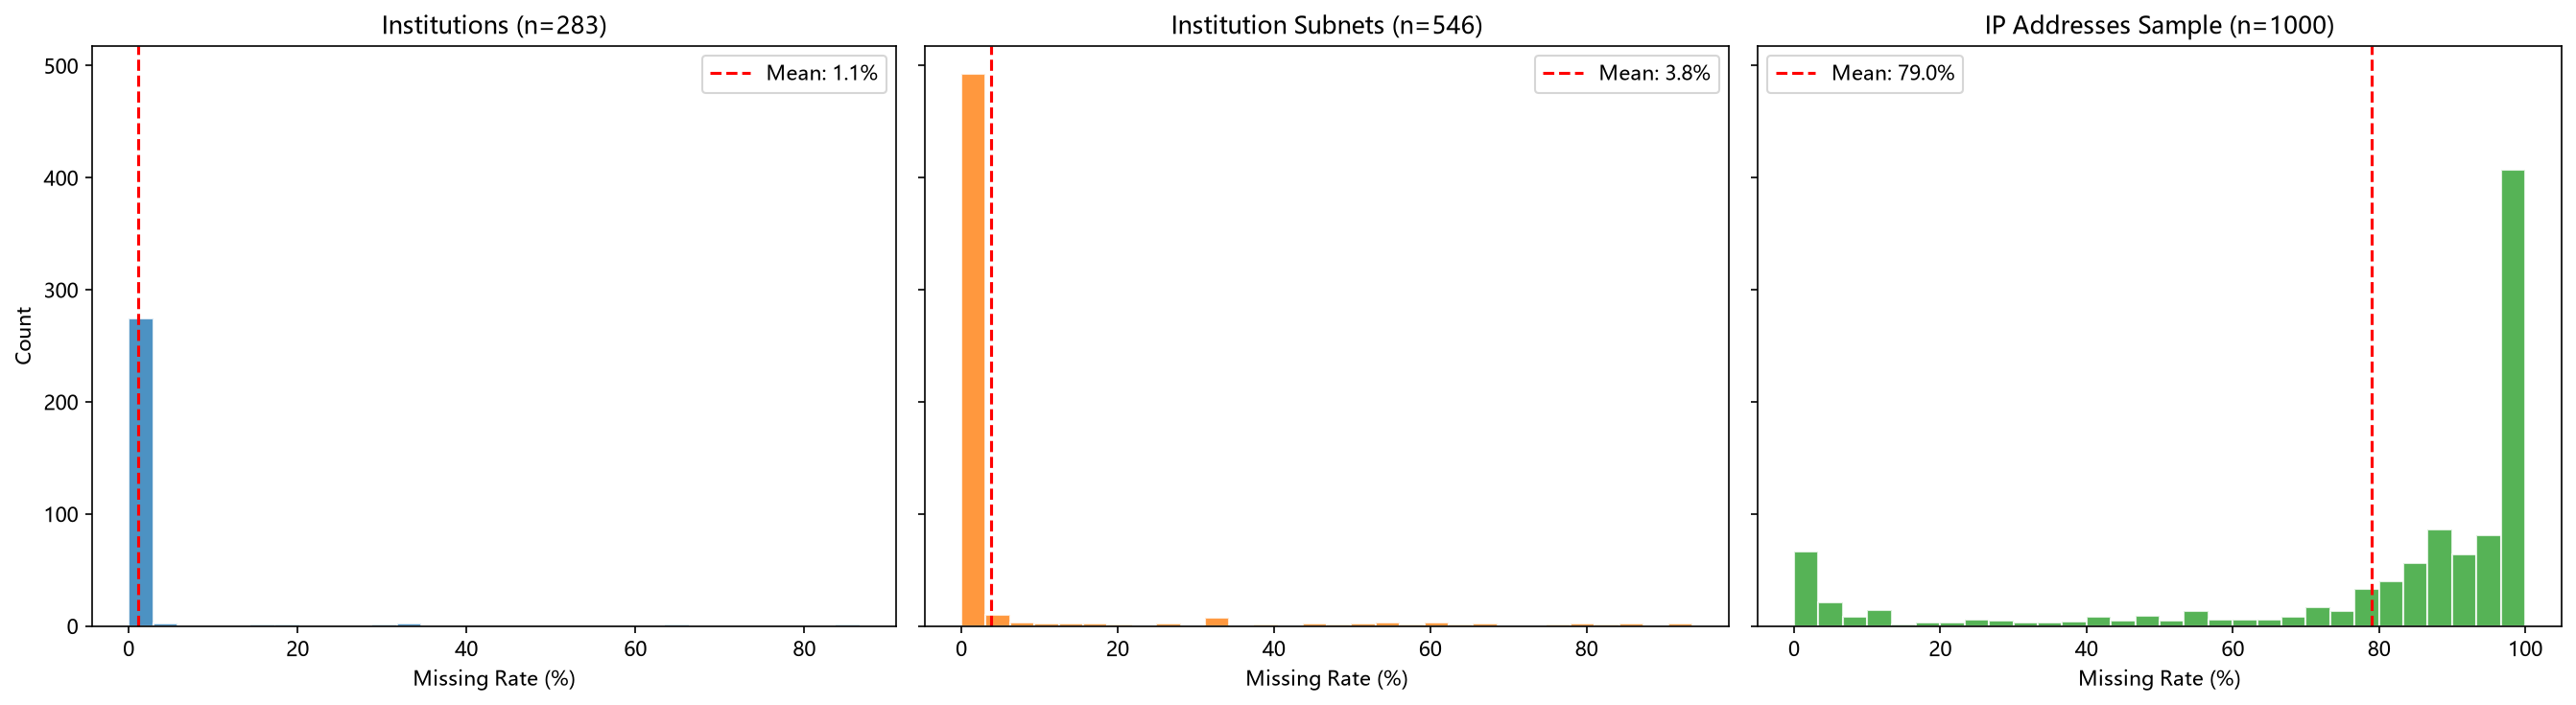

图片已保存: ..\experiments\01_eda\figures\03_missing_rate_distribution.png

参考：数据集论文报告 1h 聚合 IP 级缺失率约 60-80%，机构级接近 0%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].hist(inst_missing, bins=30, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0].axvline(inst_missing.mean(), color='red', linestyle='--', label=f"Mean: {inst_missing.mean():.1f}%")
axes[0].set_xlabel('Missing Rate (%)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Institutions (n={len(inst_missing)})')
axes[0].legend()

axes[1].hist(subnet_missing, bins=30, color='#ff7f0e', edgecolor='white', alpha=0.8)
axes[1].axvline(subnet_missing.mean(), color='red', linestyle='--', label=f"Mean: {subnet_missing.mean():.1f}%")
axes[1].set_xlabel('Missing Rate (%)')
axes[1].set_title(f'Institution Subnets (n={len(subnet_missing)})')
axes[1].legend()

axes[2].hist(ip_missing, bins=30, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[2].axvline(ip_missing.mean(), color='red', linestyle='--', label=f"Mean: {ip_missing.mean():.1f}%")
axes[2].set_xlabel('Missing Rate (%)')
axes[2].set_title(f'IP Addresses Sample (n={len(ip_missing)})')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_missing_rate_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'图片已保存: {OUTPUT_DIR / "03_missing_rate_distribution.png"}')
print(f'\n参考：数据集论文报告 1h 聚合 IP 级缺失率约 60-80%，机构级接近 0%')

**观察要点：**
- 机构级缺失率最低，因为聚合了多个 IP，总有设备在线
- IP 级缺失率最高（很多设备不 24h 在线）
- 这决定了后面不同层级需要不同的缺失值填充策略，不能一概而论

---
## Step 4: 多指标概览

**对应论文依据**：数据集论文 Table 1 + Table 2（共 18 个指标）  
**目的**：看看这 18 个指标的关系。哪些是相关的（冗余），哪些是独立的（互补信息）。

In [8]:
# 加载一条机构级数据，显示基本统计
df = pd.read_csv(DATA_DIR / 'institutions' / 'agg_1_hour' / '1.csv')

print('文件: institutions/agg_1_hour/1.csv')
print(f'行数: {len(df)}')
print(f'列数: {len(df.columns)}')
print(f'\n各列统计描述:')
df.describe()

文件: institutions/agg_1_hour/1.csv
行数: 6717
列数: 19

各列统计描述:


,id_time,n_flows,n_packets,n_bytes,sum_n_dest_asn,average_n_dest_asn,std_n_dest_asn,sum_n_dest_ports,average_n_dest_ports,std_n_dest_ports,sum_n_dest_ip,average_n_dest_ip,std_n_dest_ip,tcp_udp_ratio_packets,tcp_udp_ratio_bytes,dir_ratio_packets,dir_ratio_bytes,avg_duration,avg_ttl
count,6717.000000,6.717000e+03,6.717000e+03,6.717000e+03,6717.000000,6717.000000,6717.000000,6.717000e+03,6717.000000,6717.000000,6.717000e+03,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000,6717.000000
mean,3358.928540,9.298991e+05,5.152481e+07,5.204090e+10,171669.985708,5.912684,26.559702,5.256790e+05,19.482430,369.140572,5.838745e+05,21.307960,358.451845,0.752818,0.749300,0.471714,0.461085,20.510435,143.764258
std,1939.290162,3.043669e+05,2.925978e+07,3.302699e+10,70711.811592,0.650165,4.386273,1.880947e+05,8.089547,103.265000,1.811569e+05,6.799973,90.088224,0.054589,0.048732,0.057793,0.046947,7.046023,21.589925
min,0.000000,1.507940e+05,3.581499e+06,3.241477e+09,35038.000000,3.160000,13.760000,1.012000e+05,5.870000,123.410000,1.229260e+05,7.730000,117.000000,0.610000,0.600000,0.280000,0.310000,4.580000,111.750000
25%,1680.000000,7.165110e+05,3.174664e+07,3.144388e+10,126759.000000,5.440000,23.730000,3.648080e+05,13.920000,295.400000,4.467750e+05,16.660000,294.740000,0.710000,0.710000,0.450000,0.440000,15.830000,128.510000
50%,3359.000000,9.388460e+05,4.745221e+07,4.751019e+10,155322.000000,5.980000,27.170000,5.364140e+05,17.400000,360.500000,5.874150e+05,19.810000,356.460000,0.760000,0.750000,0.480000,0.460000,20.180000,135.010000
75%,5038.000000,1.152831e+06,6.686144e+07,6.720311e+10,199205.000000,6.380000,29.640000,6.693090e+05,23.740000,431.150000,7.154590e+05,24.570000,416.710000,0.790000,0.780000,0.500000,0.490000,23.660000,154.950000
max,6717.000000,2.247237e+06,6.873649e+08,8.145428e+11,480274.000000,7.900000,74.850000,1.018976e+06,52.880000,800.320000,1.106811e+06,55.520000,1144.550000,0.870000,0.860000,0.700000,0.660000,47.510000,214.640000


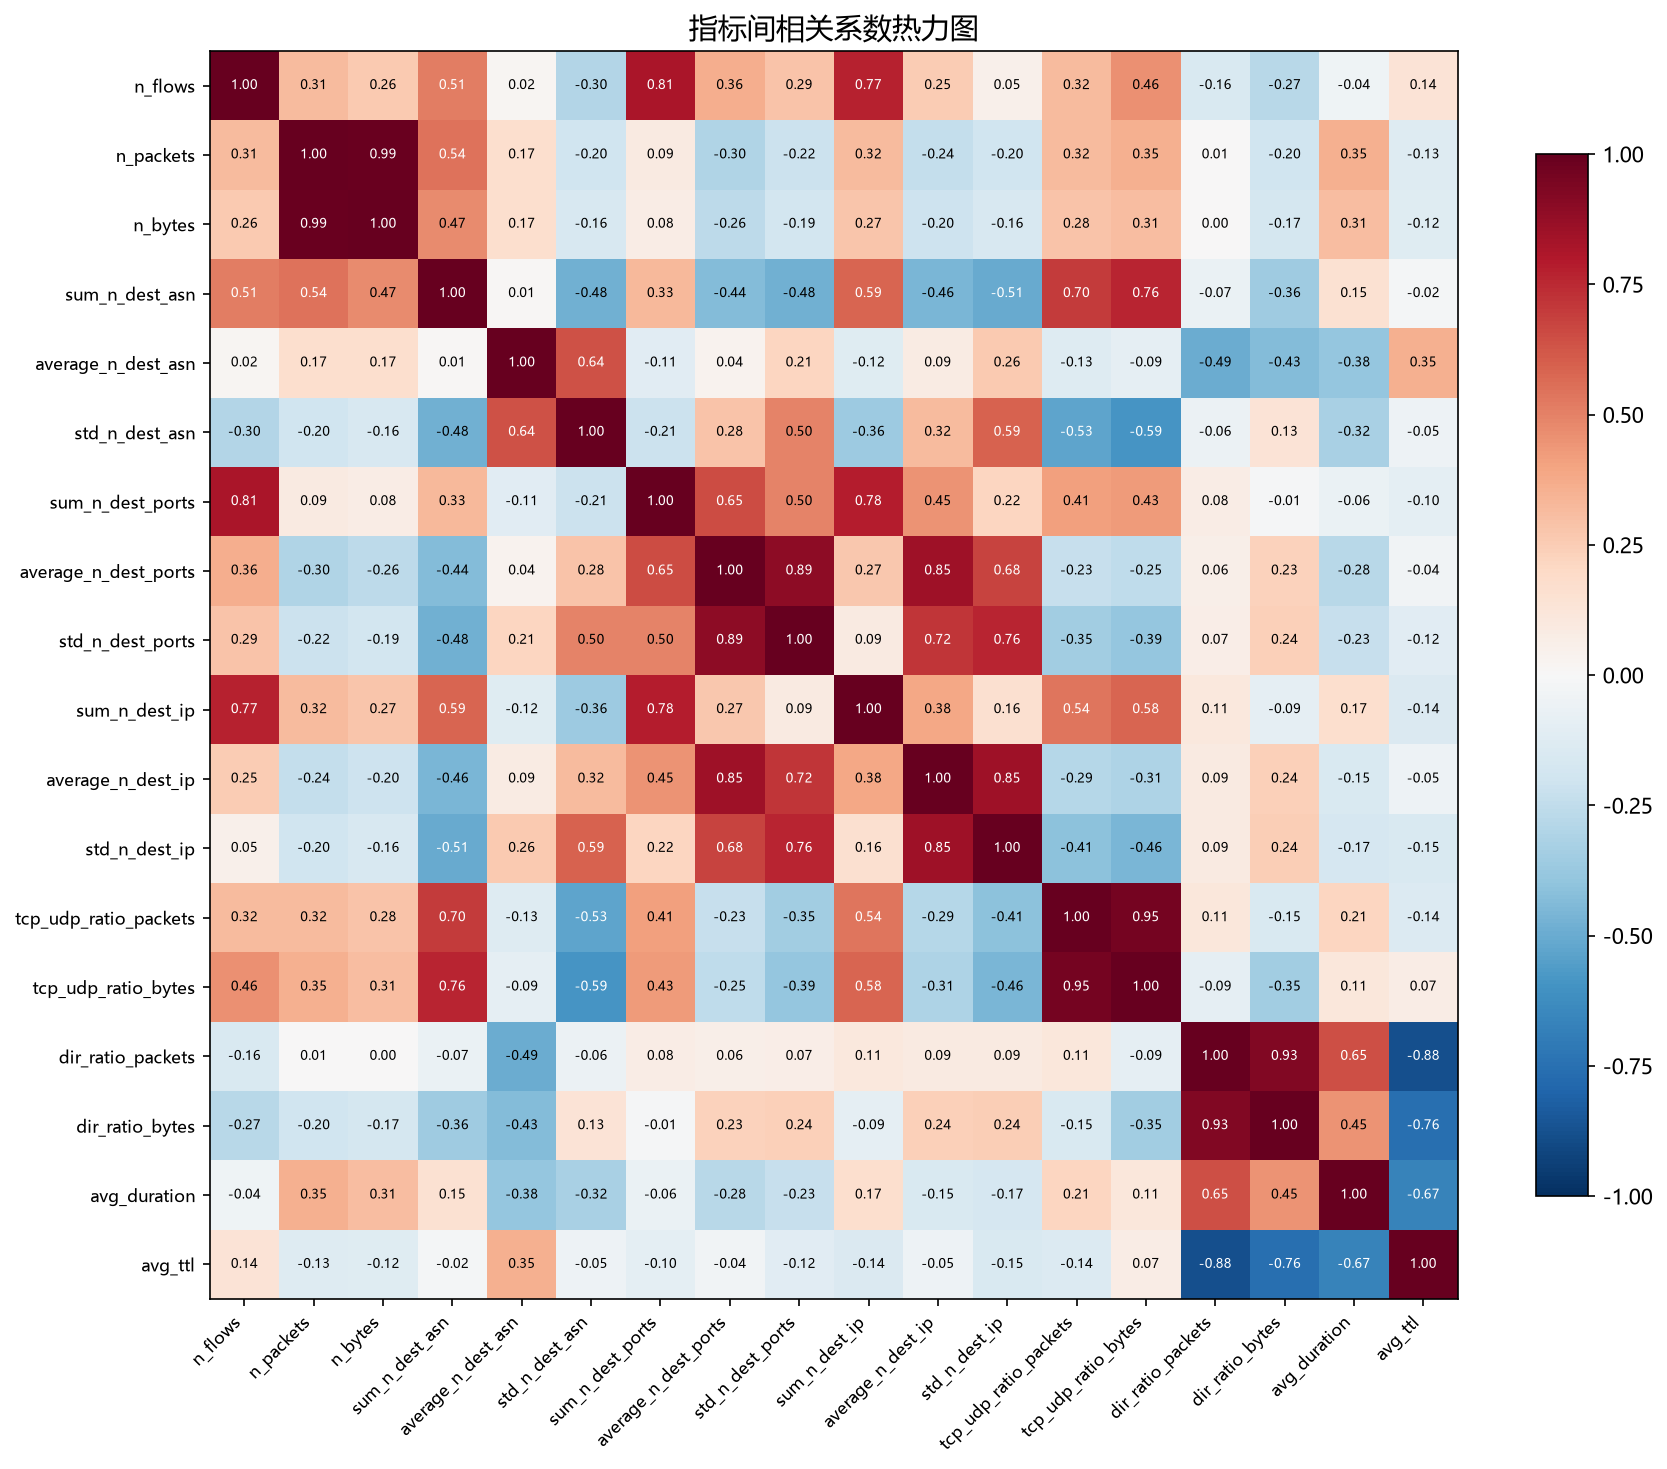

图片已保存: ..\experiments\01_eda\figures\05_metric_correlation.png


In [10]:
# 计算各指标之间的相关系数，画热力图
# 去掉 id_time 列，只看实际指标
metrics = df.drop(columns=['id_time'])
corr = metrics.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

# 标注
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

# 在格子里写数值
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

ax.set_title('指标间相关系数热力图', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_metric_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'图片已保存: {OUTPUT_DIR / "05_metric_correlation.png"}')

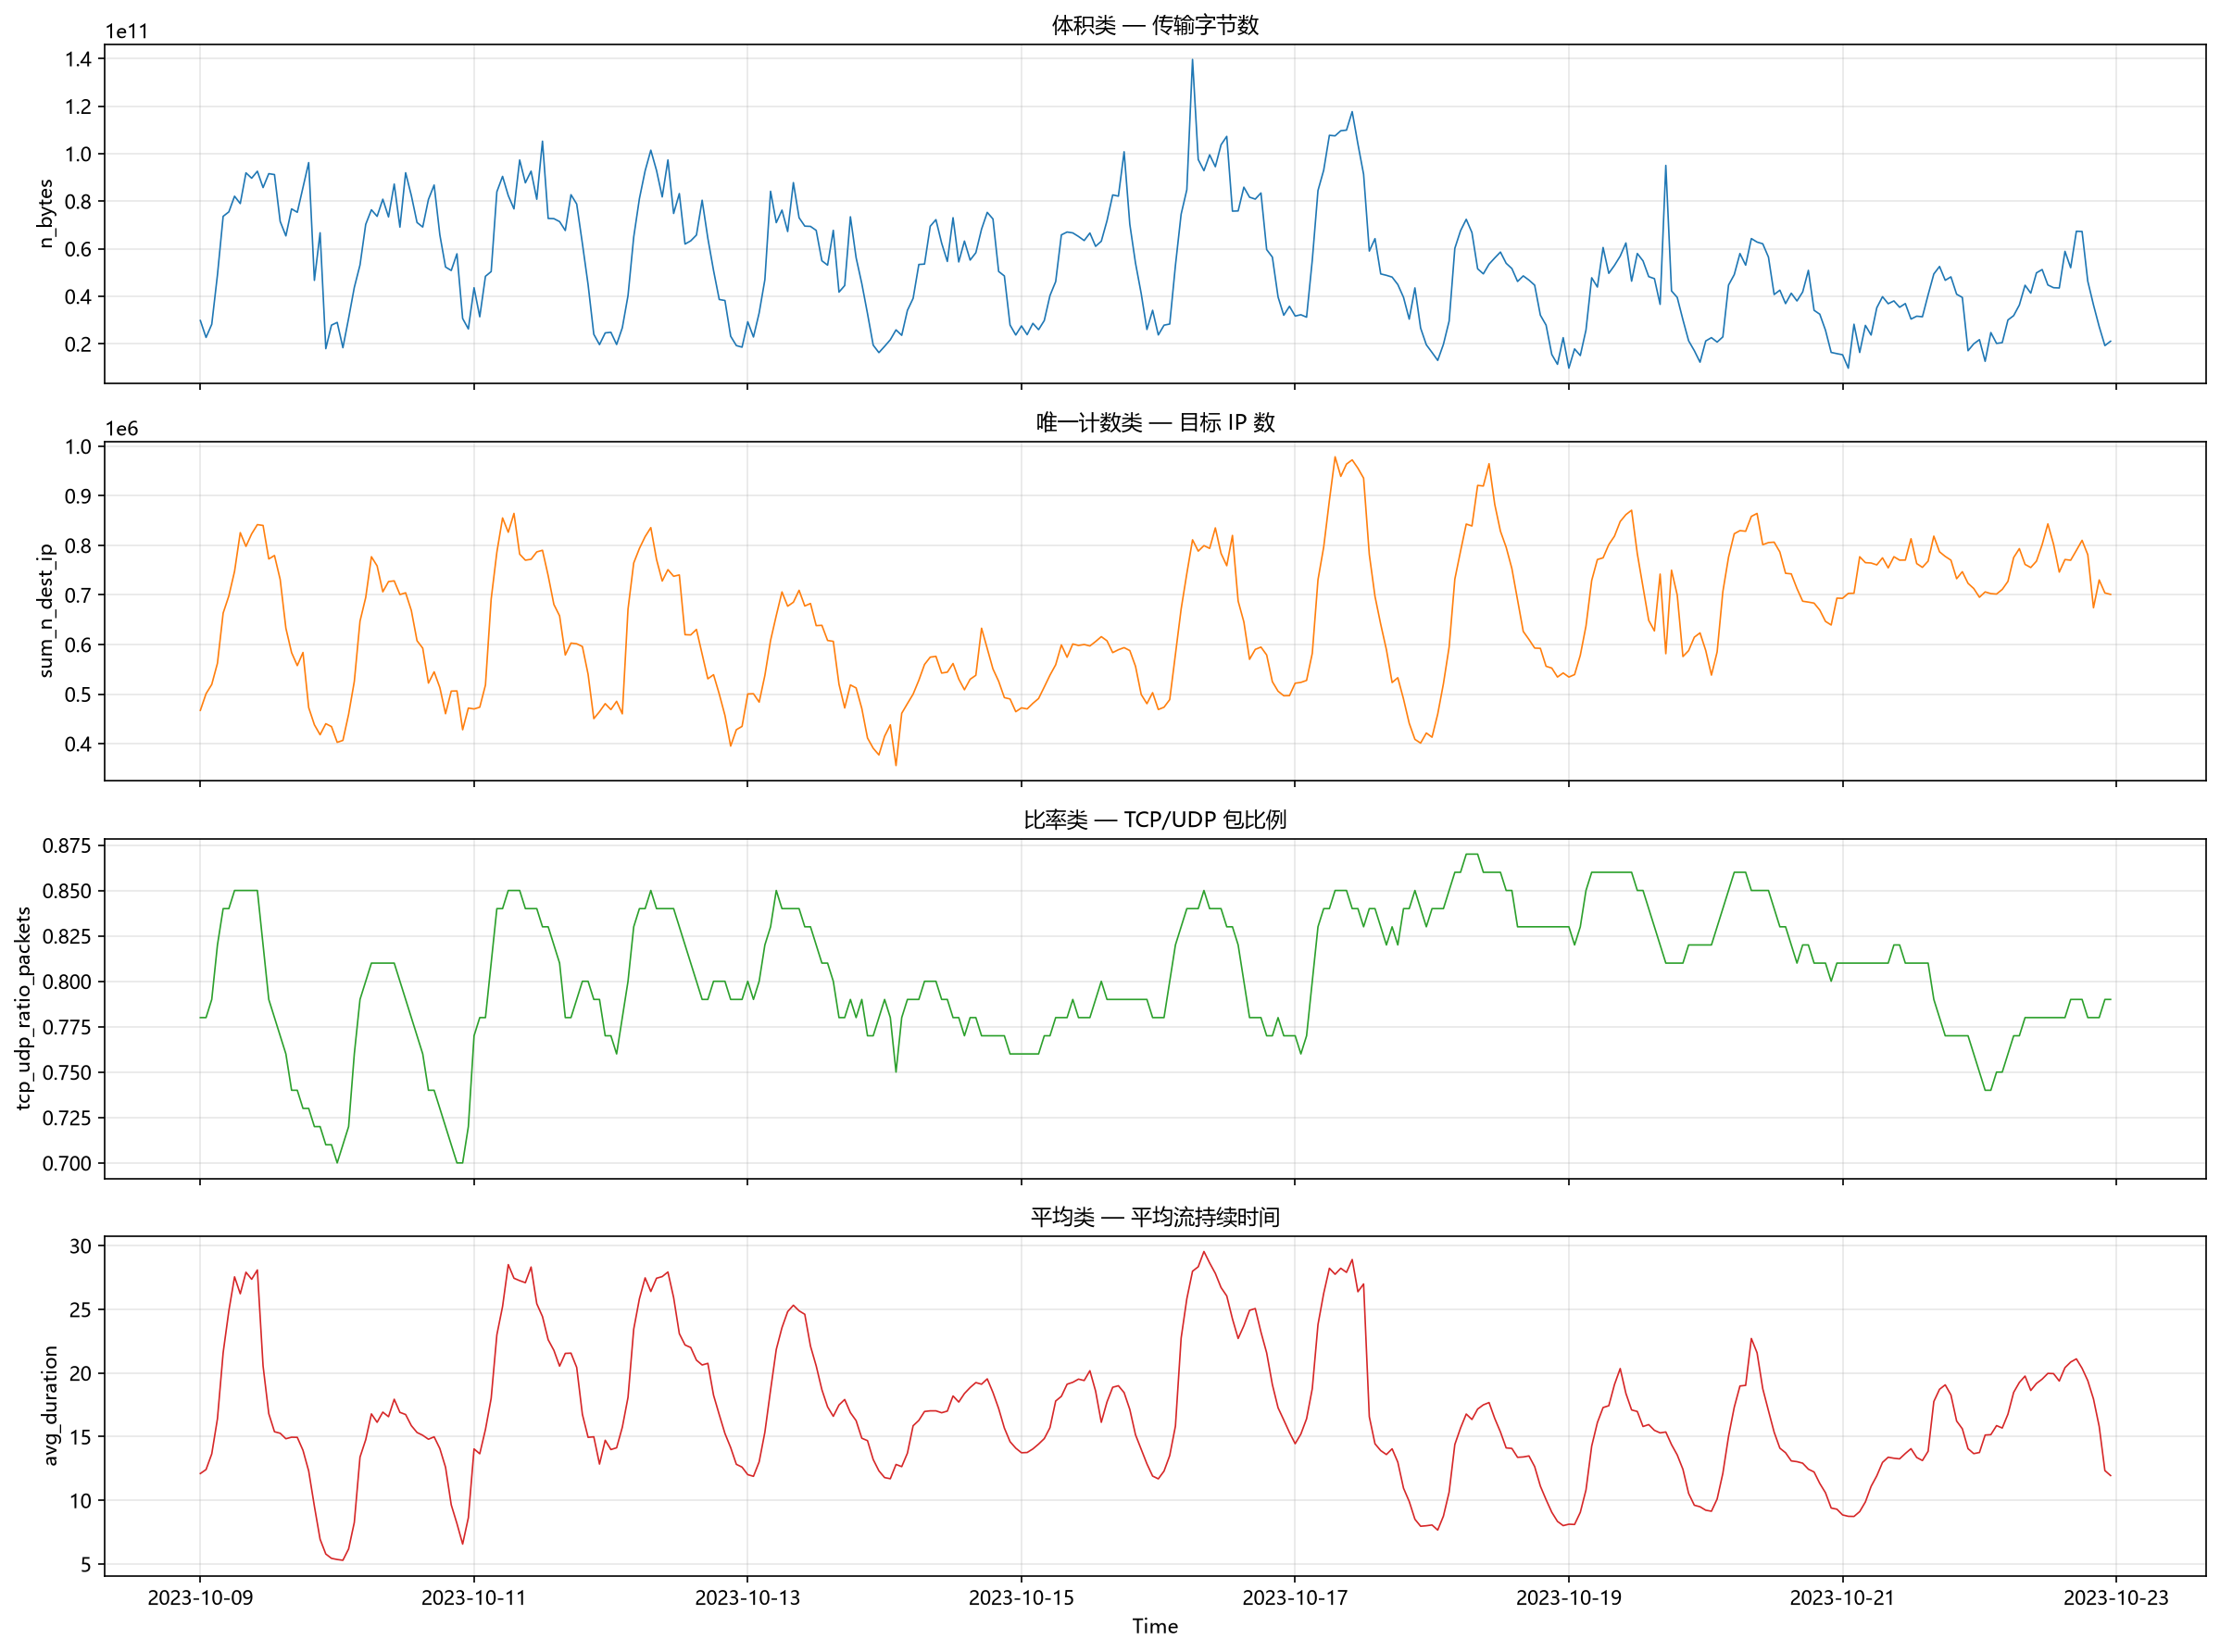

图片已保存: ..\experiments\01_eda\figures\06_representative_metrics.png


In [12]:
# 从 4 类中各选一个代表指标，分别画 4 张子图
# 用时间序列的前 2 周数据

representatives = {
    'n_bytes': '体积类 — 传输字节数',
    'sum_n_dest_ip': '唯一计数类 — 目标 IP 数',
    'tcp_udp_ratio_packets': '比率类 — TCP/UDP 包比例',
    'avg_duration': '平均类 — 平均流持续时间',
}

two_weeks_df = inst.iloc[:336].copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

for idx, (col, title) in enumerate(representatives.items()):
    ax = axes[idx]
    ax.plot(two_weeks_df.index, two_weeks_df[col], linewidth=0.8, color=f'C{idx}')
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)

plt.xlabel('Time')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_representative_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'图片已保存: {OUTPUT_DIR / "06_representative_metrics.png"}')

**观察要点：**
- **深红色块**（相关系数接近 1）：n_bytes / n_flows / n_packets 高度相关 → 选其中一个就够了，论文选 n_bytes 是合理的
- **sum 和 average/std 系列**也高度相关，因为 sum 大时 average 和 std 通常也跟着大
- 比率指标（tcp_udp_ratio, dir_ratio）与其他指标相关性弱 → 提供独立信息
- avg_duration 和 avg_ttl 也相对独立
- 主实验只用 n_bytes，但后续创新可以利用这些弱相关的指标做多变量预测

---
## Step 5: 数据分布分析

**对应论文依据**：数据集论文 Section 4.1  
**目的**：看 `n_bytes` 值分布是否偏斜。网络流量通常呈长尾分布——少量时间流量极大，大部分时间流量小。这影响后续标准化方式的选择。

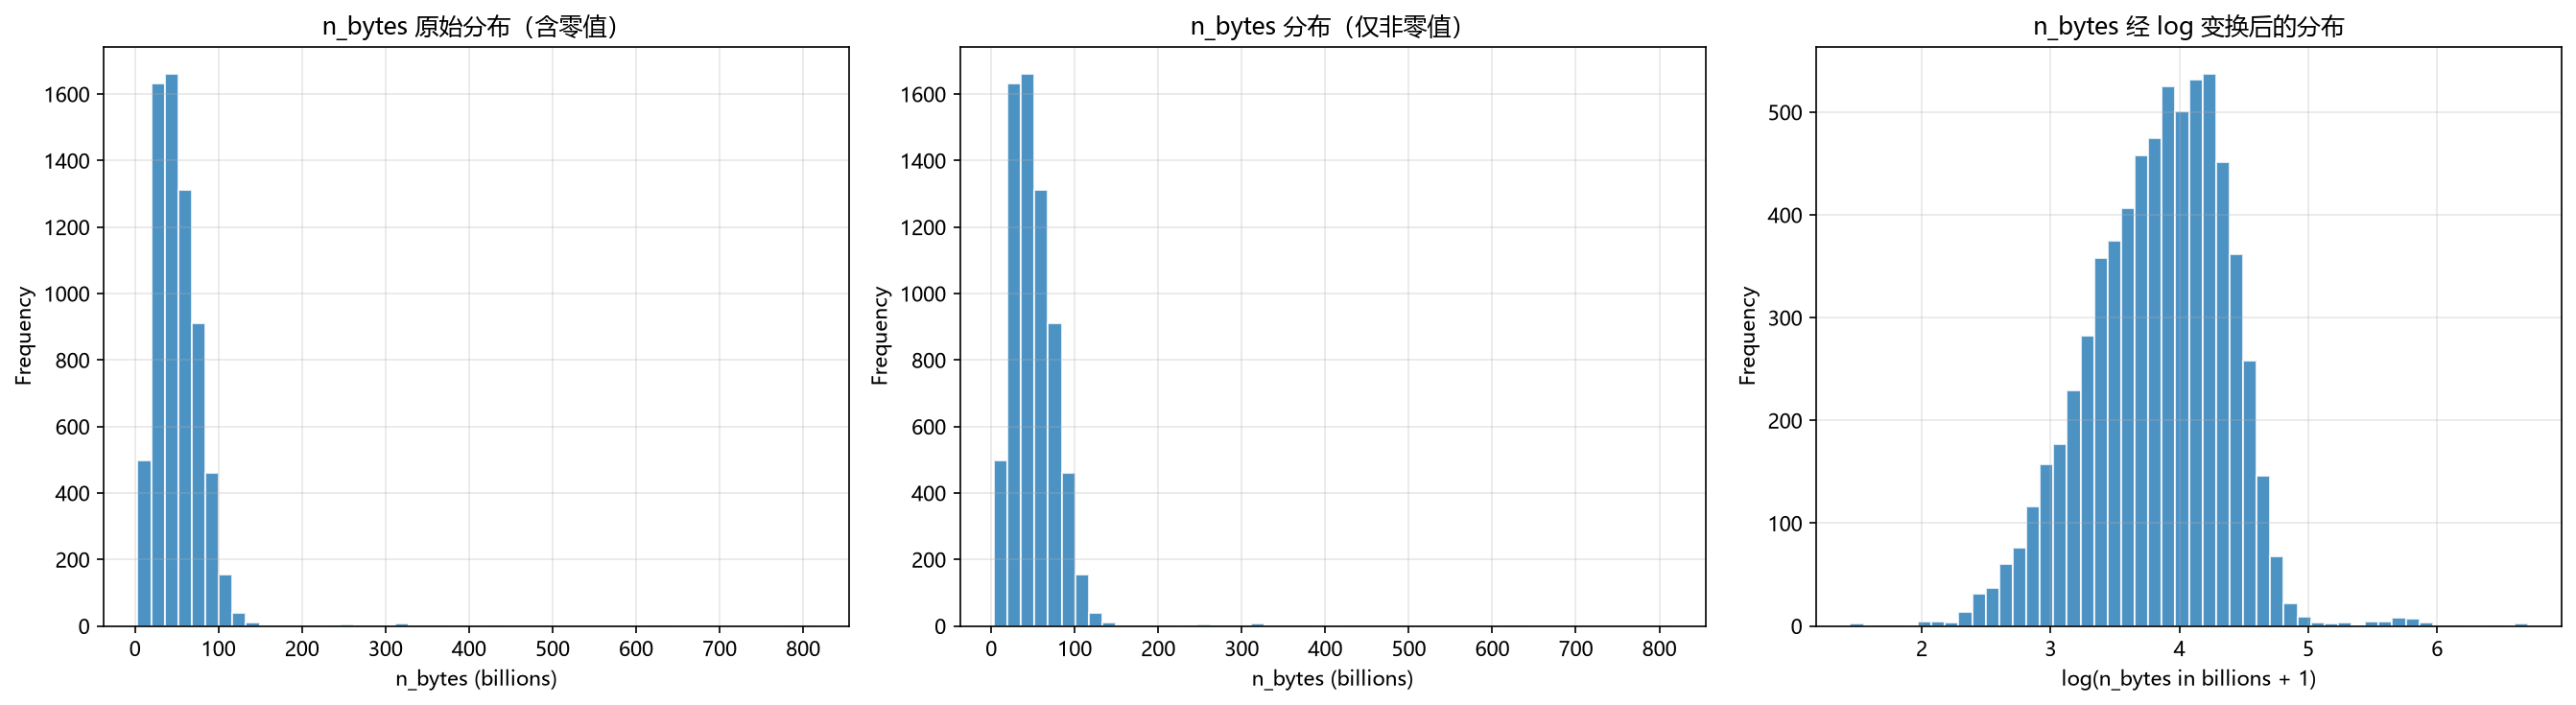

图片已保存: ..\experiments\01_eda\figures\04_data_distribution.png


In [13]:
values = df['n_bytes'].dropna()
values_no_zeros = values[values > 0]  # 排除零值单独看

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左：原始值直方图
axes[0].hist(values / 1e9, bins=50, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('n_bytes (billions)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('n_bytes 原始分布（含零值）')
axes[0].grid(True, alpha=0.3)

# 中：去掉零值后的分布
axes[1].hist(values_no_zeros / 1e9, bins=50, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('n_bytes (billions)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('n_bytes 分布（仅非零值）')
axes[1].grid(True, alpha=0.3)

# 右：log 变换后的分布
axes[2].hist(np.log1p(values_no_zeros / 1e9), bins=50, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('log(n_bytes in billions + 1)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('n_bytes 经 log 变换后的分布')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_data_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'图片已保存: {OUTPUT_DIR / "04_data_distribution.png"}')

**观察要点：**
- 原始分布：严重左偏，大多数值集中在低区间
- 去掉零值后：仍然偏斜，少量时间流量远高于平均值
- log 变换后：分布接近正态分布（钟形），更适合模型训练

论文使用 Z-score 标准化。对于网络流量这种长尾数据，先取 log 再标准化往往是更好的做法，这是后续可以探索的创新点。

---
## 总结

| 步骤 | 发现 | 对建模的影响 |
|------|------|-------------|
| 1. 层级对比 | 机构级最稳定，IP 级最稀疏 | 主实验先用机构级，IP 级做挑战实验 |
| 2. 周期性 | 存在明显的 24h 和 168h 周期 | 验证了论文的窗口选择（24/168/720）| 
| 3. 缺失值 | 机构级 ~1%，IP 级 ~79% | 不同层级需要不同的填充策略 |
| 4. 多指标 | n_bytes/n_flows/n_packets 高度相关；比率和平均指标独立 | 主实验用 n_bytes，创新点可用多变量 |
| 5. 数据分布 | 长尾分布，log 变换后更接近正态 | Z-score 标准化前可考虑 log 变换 |